# GeoPandas — praktyczny przewodnik: od podstaw po analizy przestrzenne (z odpowiednikami narzędzi QGIS)

`GeoDataFrame` to `pandas.DataFrame` z dodatkową kolumną `geometry`
(obiekty `shapely`) i CRS. Cała reszta API pandas (`.groupby`, `.merge`,
boolean indexing) działa bez zmian — notebook skupia się na tym, co jest
**specyficznie przestrzenne**, z odniesieniem do narzędzi QGIS, które te
same operacje wykonują ręcznie z poziomu GUI.

**Instalacja:**
```
pip install geopandas pyogrio mapclassify seaborn scikit-learn scipy
```
`pyogrio` — szybszy silnik I/O niż domyślny `fiona`. `mapclassify` — do
klasyfikacji kolorów. `scikit-learn`/`scipy` — do macierzy odległości i
wyszukiwania sąsiadów na dużą skalę (sekcja o odległościach).

In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point, Polygon, LineString, box

print("GeoPandas", gpd.__version__, "| silnik I/O:", gpd.options.io_engine)

GeoPandas 1.0.1 | silnik I/O: None


## 1. Dane demo

Prostokąty (`box(...)`) są czytelne do nauki pojedynczej operacji, ale nie
przypominają realnych granic administracyjnych — tu zamiast nich
**nieregularne, ale poprawne (bez samoprzecięć) poligony**, wygenerowane
wokół środka losowym promieniem w kolejnych kątach (kształt gwiaździsty
względem środka — gwarantuje brak samoprzecięć). Funkcja jest wywoływana
wielokrotnie (gminy, strefy), więc ma sens jako reużywalna funkcja, nie
kod inline.

In [2]:
def poligon_organiczny(rng, srodek, promien, liczba_wierzcholkow=14, nieregularnosc=0.35):
    """Nieregularny, ale prosty (bez samoprzecięć) Polygon wokół `srodek`
    — do symulacji naturalnego kształtu granicy administracyjnej."""
    katy = np.sort(rng.uniform(0, 2 * np.pi, liczba_wierzcholkow))
    promienie = promien * (1 + rng.uniform(-nieregularnosc, nieregularnosc, liczba_wierzcholkow))
    x = srodek[0] + promienie * np.cos(katy)
    y = srodek[1] + promienie * np.sin(katy)
    return Polygon(zip(x, y))

Text(0.5, 1.0, 'Dane demo: gminy wg powiatu (wypełnienie) + strefy (kontur)')

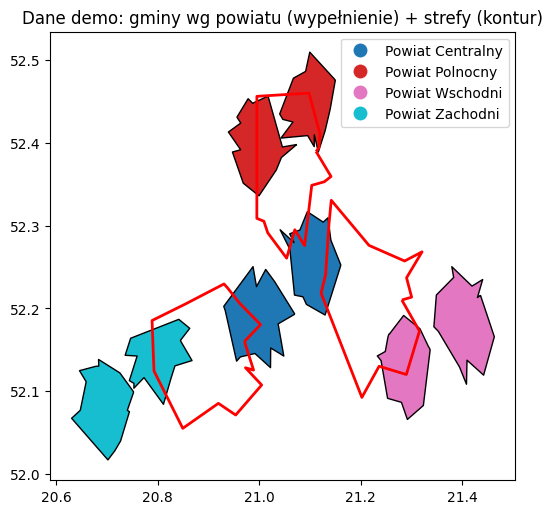

In [3]:
dane_dir = Path("geo_demo")
dane_dir.mkdir(exist_ok=True)
rng = np.random.default_rng(1)

# 4 powiaty, po 2 gminy każdy — hierarchia jak w realnym podziale administracyjnym
powiat_centra = {
    "Powiat Zachodni": (20.75, 52.12),
    "Powiat Centralny": (21.05, 52.22),
    "Powiat Wschodni": (21.35, 52.15),
    "Powiat Polnocny": (21.05, 52.42),
}
przesuniecia_gmin = [(-0.05, -0.03), (0.05, 0.03)]

rekordy_gmin = []
for powiat, (cx, cy) in powiat_centra.items():
    for i, (dx, dy) in enumerate(przesuniecia_gmin, start=1):
        rekordy_gmin.append({
            "nazwa": f"{powiat.split()[-1]}-{i}",
            "powiat": powiat,
            "ludnosc": int(rng.integers(15_000, 60_000)),
            "geometry": poligon_organiczny(rng, (cx + dx, cy + dy), promien=0.055),
        })

gminy = gpd.GeoDataFrame(rekordy_gmin, crs="EPSG:4326")

# druga warstwa poligonowa, celowo nachodząca na granice gmin — do overlay
strefy = gpd.GeoDataFrame(
    {"strefa": ["Strefa ochrony A", "Strefa inwestycyjna B", "Strefa zielona C"]},
    geometry=[
        poligon_organiczny(rng, (20.90, 52.15), promien=0.10),
        poligon_organiczny(rng, (21.20, 52.20), promien=0.11),
        poligon_organiczny(rng, (21.05, 52.38), promien=0.09),
    ],
    crs="EPSG:4326",
)

n = 400
lokalizacje_csv = pd.DataFrame({
    "id_punktu": range(1, n + 1),
    "nazwa": [f"Punkt {i}" for i in range(1, n + 1)],
    "lon": rng.uniform(20.65, 21.45, n),
    "lat": rng.uniform(52.02, 52.52, n),
    "kategoria": rng.choice(["sklep", "magazyn", "biuro"], n),
    "wartosc_sprzedazy": rng.gamma(shape=2.0, scale=500, size=n).round(2),
})

opisy_kategorii = pd.DataFrame({
    "kategoria": ["sklep", "magazyn", "biuro"],
    "opis": ["punkt sprzedaży detalicznej", "magazyn/centrum dystrybucji", "biuro administracyjne"],
    "stawka_podatku": [0.19, 0.08, 0.19],
})

gminy.to_file(dane_dir / "gminy.shp")
gminy.to_file(dane_dir / "warstwy.gpkg", layer="gminy", driver="GPKG")
strefy.to_file(dane_dir / "warstwy.gpkg", layer="strefy", driver="GPKG")
lokalizacje_csv.to_csv(dane_dir / "lokalizacje.csv", index=False)

ax = gminy.plot(column="powiat", categorical=True, legend=True, edgecolor="black", figsize=(6, 6))
strefy.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)
ax.set_title("Dane demo: gminy wg powiatu (wypełnienie) + strefy (kontur)")

## 2. Wczytywanie warstw wektorowych — SHP, GPKG, punkty z CSV i z bazy danych

### SHP vs GPKG

| | Shapefile (`.shp`) | GeoPackage (`.gpkg`) |
|---|---|---|
| Liczba plików | zestaw ≥4 (`.shp`,`.shx`,`.dbf`,`.prj`) | **jeden** plik (SQLite pod spodem) |
| Nazwy kolumn | limit **10 znaków**, ucinane bez ostrzeżenia | bez limitu |
| Warstwy w pliku | jedna warstwa = jeden zestaw plików | **wiele warstw** w jednym pliku |
| Kodowanie atrybutów | bywa problematyczne (polskie znaki) | UTF-8 domyślnie |

W nowych projektach GPKG jest praktycznie zawsze lepszym wyborem. Dla GPKG
z wieloma warstwami trzeba wskazać `layer=` — inaczej `read_file()` weźmie
pierwszą z brzegu.

In [4]:
z_shp = gpd.read_file(dane_dir / "gminy.shp")
z_gpkg = gpd.read_file(dane_dir / "warstwy.gpkg", layer="gminy")

print("warstwy w warstwy.gpkg:", gpd.list_layers(dane_dir / "warstwy.gpkg")["name"].tolist())
z_gpkg.head(2)

warstwy w warstwy.gpkg: ['siatka_zliczenia', 'punkty_z_agregacja', 'gminy', 'strefy']


,nazwa,powiat,ludnosc,geometry
0,Zachodni-1,Powiat Zachodni,36293,"POLYGON ((20.75241 52.09917, 20.72524 52.12219..."
1,Zachodni-2,Powiat Zachodni,38031,"POLYGON ((20.84435 52.16127, 20.86293 52.176, ..."


### Punkty z CSV

CSV to zwykły `pandas.DataFrame` — geometrię budujesz jawnie przez
`gpd.points_from_xy(lon, lat)`. CRS **trzeba podać ręcznie**.

In [5]:
df = pd.read_csv(dane_dir / "lokalizacje.csv")

lokalizacje = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),   # kolejność: x (lon), y (lat)
    crs="EPSG:4326",
)
lokalizacje.head(3)

,id_punktu,nazwa,lon,lat,kategoria,wartosc_sprzedazy,geometry
0,1,Punkt 1,21.146256,52.389215,biuro,1256.43,POINT (21.14626 52.38922)
1,2,Punkt 2,20.850015,52.204670,biuro,47.93,POINT (20.85001 52.20467)
2,3,Punkt 3,20.969433,52.168760,sklep,1427.72,POINT (20.96943 52.16876)


### Punkty z serwera bazodanowego

Analogicznie jak w notebooku o `mssql_python` — zapytanie zwraca kolumny
współrzędnych (albo WKT/WKB z kolumny `geography`/`geometry`), a
`GeoDataFrame` budujesz dokładnie tak samo jak z CSV. Kod referencyjny
(wymaga połączenia z bazą — nie wykonywany tutaj):

In [6]:
# df_z_bazy = pd.DataFrame(
#     (tuple(w) for w in cursor.execute(
#         "SELECT PunktID, Nazwa, Longitude, Latitude FROM dbo.Lokalizacje"
#     ).fetchall()),
#     columns=[o[0] for o in cursor.description],
# )
# lokalizacje_z_bazy = gpd.GeoDataFrame(
#     df_z_bazy,
#     geometry=gpd.points_from_xy(df_z_bazy["Longitude"], df_z_bazy["Latitude"]),
#     crs="EPSG:4326",
# )
#
# # jeśli SQL Server zwraca gotową kolumnę geometrii jako WKT/WKB:
# from shapely import wkt
# df_z_bazy["geometry"] = df_z_bazy["geom_wkt"].apply(wkt.loads)
# lokalizacje_z_bazy = gpd.GeoDataFrame(df_z_bazy, geometry="geometry", crs="EPSG:4326")

### Szybki podgląd — `.plot()`

<Axes: >

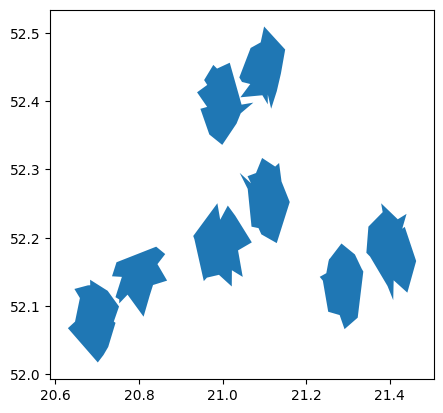

In [7]:
gminy.plot()

## 3. Parametry `gpd.read_file(...)`

Najbardziej przydatne w praktyce (część trafia dalej do `pyogrio`, jeśli
to on jest silnikiem):

| Parametr | Do czego |
|---|---|
| `layer` | która warstwa w pliku wielowarstwowym (GPKG) — nazwa albo indeks |
| `bbox` | `(xmin, ymin, xmax, ymax)` — wczytuje tylko geometrie przecinające ten zasięg |
| `mask` | jak `bbox`, ale zasięgiem jest dowolna geometria (np. jeden poligon), nie prostokąt |
| `columns` | lista kolumn atrybutowych do wczytania — pomija resztę (mniej I/O przy szerokich tabelach) |
| `rows` | `int` (pierwsze n wierszy) albo `slice()` — szybki podgląd bez ładowania całości |
| `where` | filtr atrybutowy w SQL/OGRSQL, np. `"ludnosc > 30000"` — filtrowanie **po stronie sterownika**, przed trafieniem do Pythona |
| `engine` | `"pyogrio"` (domyślny, szybszy) albo `"fiona"` |

`bbox`/`mask` i `where`/`columns` łączy się — ograniczenie geometrii i
atrybutów jednocześnie ogranicza realnie ilość danych przechodzących przez
I/O, a nie tylko to, co widać w wyniku (przewaga nad wczytaniem wszystkiego
i filtrowaniem dopiero w Pandas/GeoPandas).

In [8]:
# gminy z ludnością > 30 000, tylko dwie kolumny atrybutowe, w zadanym zasięgu
przefiltrowane = gpd.read_file(
    dane_dir / "warstwy.gpkg",
    layer="gminy",
    columns=["nazwa", "ludnosc"],
    where="ludnosc > 30000",
    bbox=(20.70, 52.00, 21.20, 52.50),
)
przefiltrowane

,ludnosc,nazwa,geometry
0,36293,Zachodni-1,"POLYGON ((20.75241 52.09917, 20.72524 52.12219..."
1,38031,Zachodni-2,"POLYGON ((20.84435 52.16127, 20.86293 52.176, ..."
2,45043,Centralny-1,"POLYGON ((21.07013 52.19313, 21.03044 52.23219..."
3,53757,Centralny-2,"POLYGON ((21.16088 52.25223, 21.14118 52.28233..."
4,51635,Polnocny-1,"POLYGON ((21.0738 52.39778, 21.04559 52.39484,..."
5,31190,Polnocny-2,"POLYGON ((21.14997 52.47555, 21.09953 52.50929..."


## 4. Układy współrzędnych — reprojekcja i zamiana stopnie ↔ metry

- **`.to_crs(...)`** na całym `GeoDataFrame` — standardowa ścieżka: masz
  warstwę, chcesz ją całą w innym układzie.
- **`pyproj.Transformer`** — gdy masz **pojedynczą parę współrzędnych** (nie
  całą warstwę) i chcesz je przeliczyć bez budowania `GeoDataFrame` — np.
  wartość wpisana ręcznie/z formularza.

### Które EPSG kiedy

| EPSG | Nazwa | Kiedy |
|---|---|---|
| **4326** | WGS84, geograficzny (stopnie) | wymiana danych, GPS, CSV ze współrzędnymi |
| **2180** | PUWG 1992, metryczny | analizy w Polsce: powierzchnia, długość, bufor w metrach |
| **3857** | Web Mercator, metryczny (zniekształcony) | kafle OSM/`.explore()`/QGIS XYZ Tiles |

**Dlaczego to ma znaczenie**: w 4326 jednostki to **stopnie, nie metry** —
`.buffer(100)` na 4326 zrobi bufor 100 *stopni*. Bufory/odległości/
powierzchnie licz na warstwie zreprojektowanej do 2180.

In [9]:
# cała warstwa
gminy_2180 = gminy.to_crs(epsg=2180)
lokalizacje_2180 = lokalizacje.to_crs(epsg=2180)
strefy_2180 = strefy.to_crs(epsg=2180)

print("stopnie (4326):", lokalizacje.geometry.iloc[0].coords[:])
print("metry   (2180):", lokalizacje_2180.geometry.iloc[0].coords[:])

stopnie (4326): [(21.14625644452395, 52.389215427797616)]
metry   (2180): [(646007.8926221817, 504754.0839189235)]


In [10]:
# pojedyncza para współrzędnych, bez GeoDataFrame
from pyproj import Transformer

przelicz_na_metry = Transformer.from_crs("EPSG:4326", "EPSG:2180", always_xy=True)
przelicz_na_stopnie = Transformer.from_crs("EPSG:2180", "EPSG:4326", always_xy=True)

x_m, y_m = przelicz_na_metry.transform(21.0122, 52.2297)   # lon, lat -> x, y (metry)
lon, lat = przelicz_na_stopnie.transform(x_m, y_m)          # z powrotem

print(f"metry: ({x_m:.1f}, {y_m:.1f})")
print(f"stopnie: ({lon:.4f}, {lat:.4f})")

metry: (637382.2, 486757.2)
stopnie: (21.0122, 52.2297)


## 5. Dodanie pól X/Y do warstwy

(QGIS: *Add X/Y Fields to Layer* / *Add Geometry Attributes*) — dla warstwy
punktowej to bezpośrednio `.geometry.x`/`.geometry.y`; dla poligonów
najpierw potrzebny punkt odniesienia (`.centroid`/`.representative_point()`,
sekcja 7).

In [11]:
lokalizacje["x"] = lokalizacje.geometry.x
lokalizacje["y"] = lokalizacje.geometry.y

lokalizacje_2180["x_2180"] = lokalizacje_2180.geometry.x
lokalizacje_2180["y_2180"] = lokalizacje_2180.geometry.y

lokalizacje[["id_punktu", "x", "y"]].head(3)

,id_punktu,x,y
0,1,21.146256,52.389215
1,2,20.850015,52.204670
2,3,20.969433,52.168760


## 6. Powierzchnia poligonu w warstwie

`.area` liczy w jednostkach **aktualnego CRS** — stąd liczymy na
`gminy_2180` (metry), nie na oryginale w 4326. Kolumna zostaje w
`gminy_2180` i jest wykorzystywana dalej (sekcja o overlay).

In [12]:
gminy_2180["powierzchnia_km2"] = gminy_2180.area / 1_000_000

gminy_2180[["nazwa", "powiat", "powierzchnia_km2"]].sort_values("powierzchnia_km2", ascending=False)

,nazwa,powiat,powierzchnia_km2
2,Centralny-1,Powiat Centralny,74.405538
5,Wschodni-2,Powiat Wschodni,72.500037
0,Zachodni-1,Powiat Zachodni,65.133426
3,Centralny-2,Powiat Centralny,64.254514
6,Polnocny-1,Powiat Polnocny,62.078482
4,Wschodni-1,Powiat Wschodni,61.558322
7,Polnocny-2,Powiat Polnocny,55.283614
1,Zachodni-2,Powiat Zachodni,54.253219


In [13]:
print(f"łączna powierzchnia wszystkich gmin: {gminy_2180['powierzchnia_km2'].sum():.1f} km²")
print(gminy_2180.groupby("powiat")["powierzchnia_km2"].sum().round(1))

łączna powierzchnia wszystkich gmin: 509.5 km²
powiat
Powiat Centralny    138.7
Powiat Polnocny     117.4
Powiat Wschodni     134.1
Powiat Zachodni     119.4
Name: powierzchnia_km2, dtype: float64


## 7. Centroidy i punkt reprezentatywny

- **`.centroid`** — środek ciężkości; dla poligonu o nietypowym kształcie
  (podkowa, pierścień) może wypaść **poza** samą geometrię.
- **`.representative_point()`** — punkt zagwarantowany **wewnątrz**
  geometrii (QGIS: *Point on Surface*) — właściwy wybór na etykiety, gdy
  kształt może być niewypukły (jak nasze organiczne gminy).

Wzorzec liczenia centroidu w układzie metrycznym i powrotu do stopni do
wizualizacji — częsty w praktyce, bo centroid liczony wprost na 4326
(stopniach) bywa lekko przesunięty względem geometrycznie poprawnego
środka w metrach, przy większych/rozciągniętych poligonach.

<Axes: >

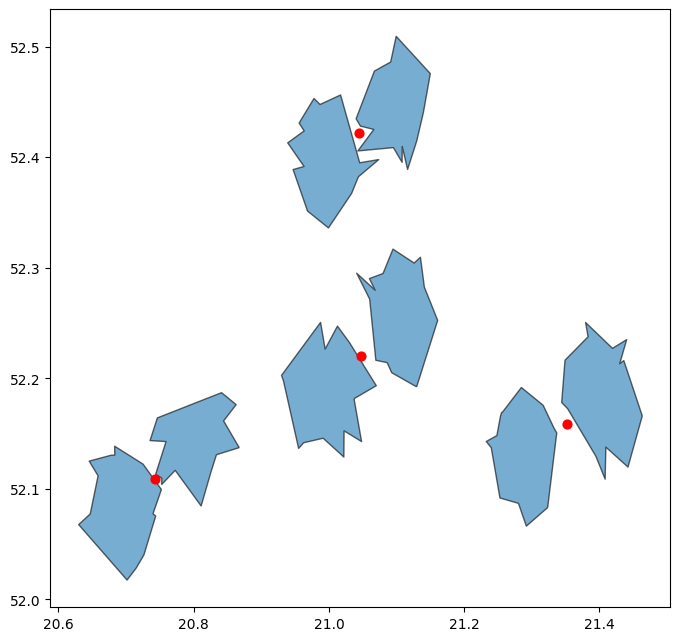

In [14]:
powiaty_gpd = gminy.dissolve(by="powiat", aggfunc={"ludnosc": "sum"}).reset_index()

powiaty_gpd = powiaty_gpd.to_crs(2180)

powiaty_gpd["centroid"] = (
    powiaty_gpd
    .centroid
    .to_crs(4326)
)

powiaty_gpd_4326 = powiaty_gpd.to_crs(4326)

ax = powiaty_gpd_4326.plot(figsize=(8, 8), edgecolor="black", alpha=0.6)

powiaty_gpd_4326.set_geometry("centroid").plot(
    ax=ax,
    color="red",
    markersize=40,
)

C:\Users\pkawk\AppData\Local\Temp\ipykernel_14032\919876964.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gmina_przykladowa.centroid.plot(ax=ax, color="red", markersize=40, label="centroid")


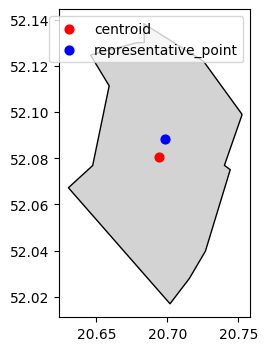

In [15]:
# porównanie centroid vs punkt reprezentatywny na pojedynczej, nieregularnej gminie
gmina_przykladowa = gminy.iloc[[0]]

ax = gmina_przykladowa.plot(color="lightgrey", edgecolor="black", figsize=(4, 4))
gmina_przykladowa.centroid.plot(ax=ax, color="red", markersize=40, label="centroid")
gmina_przykladowa.representative_point().plot(ax=ax, color="blue", markersize=40, label="representative_point")
ax.legend()

## 8. Bufor wokół punktów

(QGIS: *Vector > Geoprocessing Tools > Buffer*) — bufor liczy się w
jednostkach CRS, więc reprojekcja do 2180 przed `.buffer()` i powrót do
4326 tylko do wizualizacji to standardowy wzorzec.

<Axes: >

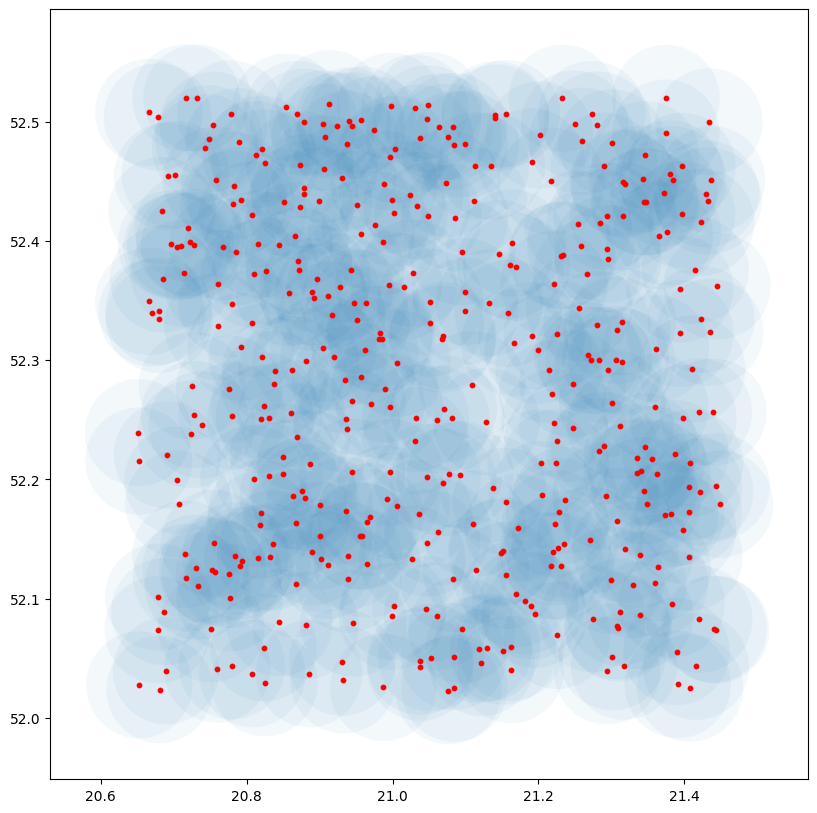

In [16]:
# ============================================
# BUFORY 5 KM DLA PUNKTÓW
# ============================================

# 1. Upewniamy się, że punkty są w EPSG:4326
lokalizacje = lokalizacje.to_crs(epsg=4326)

# 2. Tymczasowa transformacja do układu metrycznego
#    EPSG:2180 -> współrzędne w metrach
lokalizacje_2180 = lokalizacje.to_crs(epsg=2180)

# 3. Tworzymy bufor 5 km wokół każdego punktu
bufory = lokalizacje_2180.copy()
bufory["geometry"] = bufory.geometry.buffer(5000)

# 4. Wracamy z buforami do EPSG:4326
#    Dzięki temu wizualizacja będzie miała osie w stopniach
bufory = bufory.to_crs(epsg=4326)

# ============================================
# WIZUALIZACJA
# ============================================

ax = bufory.plot(
    figsize=(10, 10),
    alpha=0.05,
)

lokalizacje.plot(
    ax=ax,
    markersize=10,
    color="red",
)

## 9. Predicate — pełny przegląd

`predicate` (w `sjoin`, `.overlay`, albo bezpośrednio jako metoda —
`geom_a.within(geom_b)`) określa **jaką relację przestrzenną** sprawdzasz.
To jedna z tych rzeczy, gdzie warto zobaczyć różnicę na obrazku, nie tylko
w definicji:

| Predicate | Prawda, gdy... |
|---|---|
| `intersects` | geometrie mają **jakikolwiek** wspólny punkt (najszersza relacja — obejmuje wszystkie poniższe) |
| `within` | A leży **całkowicie wewnątrz** B (odwrotność `contains`) |
| `contains` | B leży **całkowicie wewnątrz** A |
| `touches` | stykają się **tylko brzegiem** (granicą), bez wspólnego wnętrza |
| `crosses` | przecinają się, ale żadna nie zawiera drugiej **w całości** (typowo: linia przez poligon) |
| `overlaps` | częściowo się nakładają, obie mają fragment **poza** drugą (ten sam wymiar geometrii) |
| `disjoint` | **brak** jakiegokolwiek wspólnego punktu (przeciwieństwo `intersects`) |
| `dwithin` (tylko `sjoin`) | odległość między geometriami ≤ zadana wartość — jedyny predicate, który **nie** wymaga stykania się |

In [17]:
kwadrat_a = Polygon([(0, 0), (2, 0), (2, 2), (0, 2)])
kwadrat_within = Polygon([(0.5, 0.5), (1, 0.5), (1, 1), (0.5, 1)])       # cały w środku A
kwadrat_overlap = Polygon([(1, 1), (3, 1), (3, 3), (1, 3)])               # nachodzi częściowo
kwadrat_touch = Polygon([(2, 0), (4, 0), (4, 2), (2, 2)])                 # styka się krawędzią
linia_cross = LineString([(1, -1), (1, 3)])                               # przecina na wylot
kwadrat_disjoint = Polygon([(6, 6), (7, 6), (7, 7), (6, 7)])              # osobno

wyniki = pd.DataFrame({
    "geometria": ["within", "overlaps", "touches", "crosses (linia)", "disjoint"],
    "intersects": [kwadrat_a.intersects(g) for g in
                    [kwadrat_within, kwadrat_overlap, kwadrat_touch, linia_cross, kwadrat_disjoint]],
    "within": [g.within(kwadrat_a) for g in
               [kwadrat_within, kwadrat_overlap, kwadrat_touch, linia_cross, kwadrat_disjoint]],
    "touches": [kwadrat_a.touches(g) for g in
                [kwadrat_within, kwadrat_overlap, kwadrat_touch, linia_cross, kwadrat_disjoint]],
    "crosses": [kwadrat_a.crosses(g) for g in
                [kwadrat_within, kwadrat_overlap, kwadrat_touch, linia_cross, kwadrat_disjoint]],
    "overlaps": [kwadrat_a.overlaps(g) for g in
                 [kwadrat_within, kwadrat_overlap, kwadrat_touch, linia_cross, kwadrat_disjoint]],
})
wyniki

,geometria,intersects,within,touches,crosses,overlaps
0,within,True,True,False,False,False
1,overlaps,True,False,False,False,True
2,touches,True,False,True,False,False
3,crosses (linia),True,False,False,True,False
4,disjoint,False,False,False,False,False


In [18]:
# dwithin — jedyny predicate liczący odległość, nie styk geometrii
punkt_blisko = gpd.GeoDataFrame(geometry=[Point(2.5, 1)], crs=None)
gdf_a = gpd.GeoDataFrame(geometry=[kwadrat_a], crs=None)

print("dotyka (intersects)?", gdf_a.intersects(punkt_blisko.geometry.iloc[0]).iloc[0])
print("w promieniu 1.0 (dwithin)?",
      gpd.sjoin(punkt_blisko, gdf_a, predicate="dwithin", distance=1.0).shape[0] > 0)

dotyka (intersects)? False
w promieniu 1.0 (dwithin)? True


## 10. Siatka (grid) i zliczanie punktów w poligonach

(QGIS: *Create Grid* + *Count Points in Polygon*) — jedna technika
obsługuje oba przypadki (siatka **i** realne poligony typu gminy):
`predicate="within"` (sekcja 9) w `sjoin`, potem `groupby().size()`.

### 10a. Zliczanie w istniejących poligonach (gminy)

In [19]:
# obie warstwy mają kolumnę "nazwa" -> zmieniamy nazwę po stronie gmin przed
# joinem, żeby nie polegać na automatycznych sufiksach _left/_right
gminy_join = gminy.rename(columns={"nazwa": "nazwa_gminy"})
punkty_z_gmina = gpd.sjoin(lokalizacje, gminy_join, how="left", predicate="within")

liczba_punktow_w_gminie = (
    punkty_z_gmina.groupby("nazwa_gminy").size().rename("liczba_punktow")
)
gminy_z_liczba = gminy.merge(liczba_punktow_w_gminie, left_on="nazwa", right_index=True, how="left")
gminy_z_liczba[["nazwa", "powiat", "ludnosc", "liczba_punktow"]].sort_values("liczba_punktow", ascending=False)

,nazwa,powiat,ludnosc,liczba_punktow
5,Wschodni-2,Powiat Wschodni,46405,14
1,Zachodni-2,Powiat Zachodni,38031,12
6,Polnocny-1,Powiat Polnocny,51635,10
2,Centralny-1,Powiat Centralny,45043,10
4,Wschodni-1,Powiat Wschodni,22762,7
7,Polnocny-2,Powiat Polnocny,31190,7
0,Zachodni-1,Powiat Zachodni,36293,6
3,Centralny-2,Powiat Centralny,53757,4


### 10b. Budowa siatki (fishnet) i zliczanie w jej komórkach

Text(0.5, 1.0, 'Siatka 0.05° — liczba punktów w komórce')

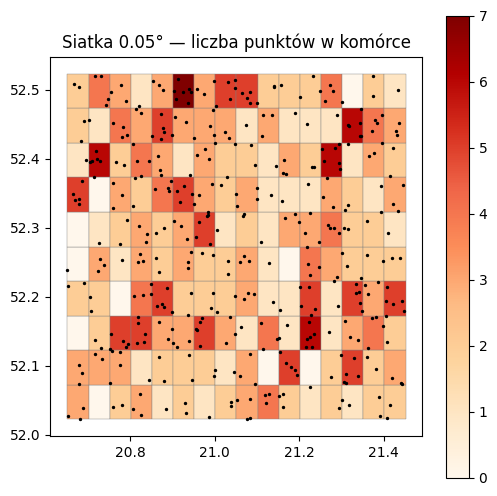

In [20]:
krok = 0.05   # rozmiar oczka siatki w stopniach
xmin, ymin, xmax, ymax = lokalizacje.total_bounds

komorki = [
    box(x, y, x + krok, y + krok)
    for x in np.arange(xmin, xmax, krok)
    for y in np.arange(ymin, ymax, krok)
]
siatka = gpd.GeoDataFrame({"id_komorki": range(len(komorki))}, geometry=komorki, crs="EPSG:4326")

punkty_z_komorka = gpd.sjoin(lokalizacje, siatka, how="left", predicate="within")
liczba_w_komorce = punkty_z_komorka.groupby("id_komorki").size().rename("n_punktow")
siatka = siatka.merge(liczba_w_komorce, on="id_komorki", how="left").fillna({"n_punktow": 0})

ax = siatka.plot(column="n_punktow", cmap="OrRd", edgecolor="grey", linewidth=0.3, legend=True, figsize=(6, 6))
lokalizacje.plot(ax=ax, color="black", markersize=2)
ax.set_title(f"Siatka {krok}° — liczba punktów w komórce")

> **Alternatywa: siatka heksagonalna (H3, biblioteka `h3`)**. Heksagony
> mają stałą odległość do środków sąsiednich komórek (kwadraty — nie),
> więc lepiej nadają się do analiz gęstości/sąsiedztwa.
> `h3.latlng_to_cell(lat, lon, rozdzielczość)` przypisuje punkt do komórki,
> `h3.cell_to_boundary(...)` zwraca jej geometrię — dalej ten sam
> `groupby().size()`.

<Axes: >

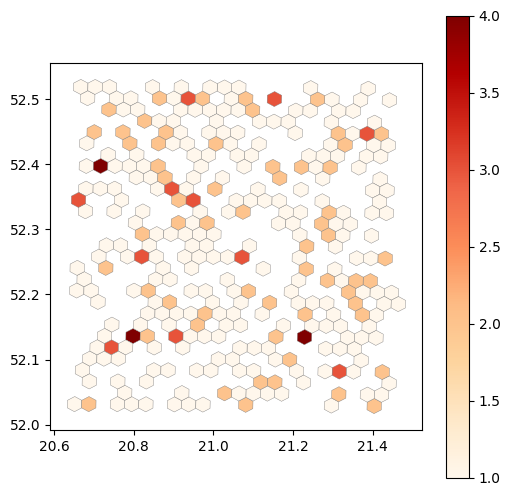

In [21]:
import h3

rozdzielczosc_h3 = 7
lokalizacje["h3_id"] = [h3.latlng_to_cell(pt.y, pt.x, rozdzielczosc_h3) for pt in lokalizacje.geometry]

liczba_w_hex = lokalizacje.groupby("h3_id").size().rename("n_punktow")
siatka_h3 = gpd.GeoDataFrame(
    {"h3_id": liczba_w_hex.index, "n_punktow": liczba_w_hex.values},
    geometry=[Polygon([(lon, lat) for lat, lon in h3.cell_to_boundary(h)]) for h in liczba_w_hex.index],
    crs="EPSG:4326",
)
siatka_h3.plot(column="n_punktow", cmap="OrRd", edgecolor="grey", linewidth=0.3, legend=True, figsize=(6, 6))

## 11. Zliczanie punktów w zadanej odległości / liście odległości

Pojedynczy promień to bufor + `within`/`sindex.query`. Lista promieni —
np. "ile punktów w promieniu 1 km, ile między 1 a 3 km, ile między 3 a
5 km" (analiza pierścieniowa) — to różnica dwóch buforów na każdym progu.

In [22]:
punkt_centralny = lokalizacje_2180.geometry.iloc[0]

# pojedynczy promień
for promien_km in [1, 3, 5]:
    bufor = punkt_centralny.buffer(promien_km * 1000)
    liczba = lokalizacje_2180.within(bufor).sum()
    print(f"promień {promien_km} km: {liczba} punktów")

promień 1 km: 1 punktów
promień 3 km: 4 punktów
promień 5 km: 7 punktów


In [23]:
# lista promieni jako pierścienie (nie kumulatywnie, tylko dany zakres)
progi_m = [0, 1000, 3000, 5000]

wyniki_pierscieni = []
for i in range(len(progi_m) - 1):
    pierscien = punkt_centralny.buffer(progi_m[i + 1]).difference(punkt_centralny.buffer(progi_m[i]))
    liczba = lokalizacje_2180.within(pierscien).sum()
    wyniki_pierscieni.append({
        "zakres_km": f"{progi_m[i]/1000:.0f}-{progi_m[i+1]/1000:.0f}",
        "liczba_punktow": liczba,
    })

pd.DataFrame(wyniki_pierscieni)

,zakres_km,liczba_punktow
0,0-1,1
1,1-3,3
2,3-5,3


## 12. Odległości

### 12a. Punkt-punkt i macierz odległości

Dla **dwóch** punktów wystarczy `.distance()`. Dla **wielu** punktów
naraz — pełna macierz odległości NxN (każdy z każdym) — przydatna np. jako
wejście do klastrowania hierarchicznego, analizy OD (origin-destination)
albo wyszukiwania duplikatów leżących blisko siebie.

In [24]:
a, b = lokalizacje_2180.geometry.iloc[0], lokalizacje_2180.geometry.iloc[1]
print(f"odległość punkt-punkt: {a.distance(b):.1f} m")

odległość punkt-punkt: 28798.5 m


In [25]:
from sklearn.metrics import pairwise_distances

podzbior = lokalizacje_2180.iloc[:8]
wspolrzedne_podzbior = np.column_stack([podzbior.geometry.x, podzbior.geometry.y])

macierz_odleglosci = pairwise_distances(wspolrzedne_podzbior)   # NxN, w metrach (CRS = 2180)
pd.DataFrame(macierz_odleglosci, index=podzbior["id_punktu"], columns=podzbior["id_punktu"]).round(0)

id_punktu,1,2,3,4,5,6,7,8
id_punktu,,,,,,,,
1,0.0,28799.0,27326.0,26440.0,31759.0,36944.0,31081.0,31740.0
2,28799.0,0.0,9088.0,38112.0,24530.0,24582.0,29668.0,29772.0
3,27326.0,9088.0,0.0,30364.0,15445.0,16017.0,36735.0,36960.0
4,26440.0,38112.0,30364.0,0.0,20367.0,26352.0,55082.0,55632.0
5,31759.0,24530.0,15445.0,20367.0,0.0,6247.0,50430.0,50765.0
6,36944.0,24582.0,16017.0,26352.0,6247.0,0.0,52587.0,52846.0
7,31081.0,29668.0,36735.0,55082.0,50430.0,52587.0,0.0,730.0
8,31740.0,29772.0,36960.0,55632.0,50765.0,52846.0,730.0,0.0


### 12b. Odległości dla wielu punktów naraz — scikit-learn (`BallTree`)

`sindex.nearest()` z GeoPandas (już użyte wcześniej) sprawdza się do
**pojedynczego** zapytania. Gdy potrzebujesz najbliższego sąsiada dla
**każdego** punktu w warstwie naraz — przy większej liczbie punktów szybciej
zbudować `BallTree`/`KDTree` raz i odpytać go wektorowo, niż wywoływać
`sindex.nearest()` w pętli Pythona po każdym punkcie z osobna.

In [26]:
from sklearn.neighbors import BallTree

wspolrzedne = np.column_stack([lokalizacje_2180.geometry.x, lokalizacje_2180.geometry.y])
drzewo = BallTree(wspolrzedne)

# k=2, bo pierwszy "sąsiad" każdego punktu to on sam (odległość 0)
odleglosci, indeksy = drzewo.query(wspolrzedne, k=2)
lokalizacje_2180["najblizszy_sasiad_m"] = odleglosci[:, 1]

lokalizacje_2180[["id_punktu", "najblizszy_sasiad_m"]].sort_values("najblizszy_sasiad_m").head()

,id_punktu,najblizszy_sasiad_m
209,210,184.086504
395,396,184.086504
371,372,211.540246
105,106,211.540246
67,68,227.722626


### 12c. Odległość geodezyjna — bez reprojekcji

Gdy interesuje Cię *rzeczywista* odległość po powierzchni Ziemi między
punktami w 4326, a nie chcesz reprojektować całej warstwy —
`pyproj.Geod` liczy ją bezpośrednio na współrzędnych geograficznych
(dokładniej niż przybliżenie płaskie z 2180 przy dużych dystansach, np.
dla całego kraju).

In [27]:
from pyproj import Geod

geod = Geod(ellps="WGS84")
p1, p2 = lokalizacje.geometry.iloc[0], lokalizacje.geometry.iloc[1]

_, _, dystans_geodezyjny_m = geod.inv(p1.x, p1.y, p2.x, p2.y)
print(f"odległość geodezyjna (WGS84): {dystans_geodezyjny_m:.1f} m")
print(f"odległość na 2180 (płaska)  : {a.distance(b):.1f} m")

odległość geodezyjna (WGS84): 28812.1 m
odległość na 2180 (płaska)  : 28798.5 m


## 13. Działania na warstwach — overlay (intersection, difference, union) + agregacja

(QGIS: *Intersection / Difference / Union / Symmetrical Difference*) —
jedna funkcja `gpd.overlay(a, b, how=...)`.

intersection: 7 | difference: 8 | union: 18


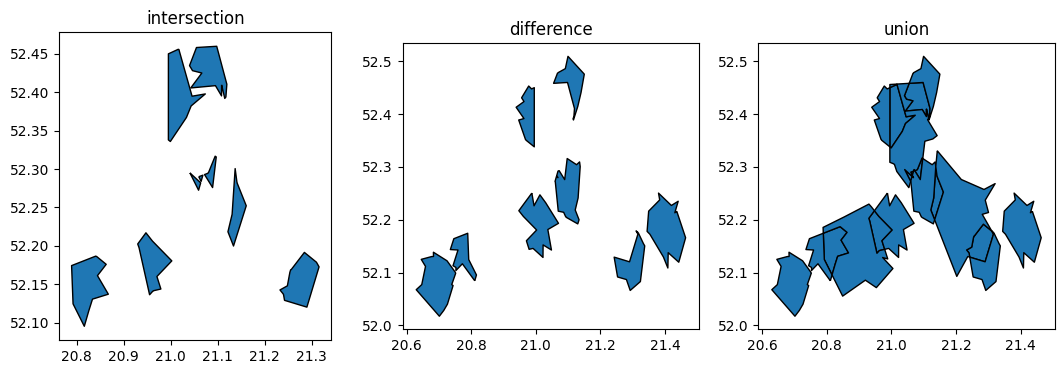

In [28]:
przeciecie = gpd.overlay(gminy, strefy, how="intersection")
roznica = gpd.overlay(gminy, strefy, how="difference")
suma = gpd.overlay(gminy, strefy, how="union")

print("intersection:", len(przeciecie), "| difference:", len(roznica), "| union:", len(suma))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (dane, tytul) in zip(axes, [(przeciecie, "intersection"), (roznica, "difference"), (suma, "union")]):
    dane.plot(ax=ax, edgecolor="black")
    ax.set_title(tytul)

### Agregacja po overlay — `gpd.overlay` nie ma parametru `aggfunc`

`overlay(how="intersection")` zwraca **jeden wiersz na każdy fragment**
przecięcia (gmina × strefa) — żeby dostać np. "jaki % powierzchni gminy
objęty jest jakąkolwiek strefą", trzeba policzyć powierzchnię fragmentów i
**zagregować z powrotem** po kluczu gminy (`groupby` + `merge`) — to jest
ten brakujący "aggfunc" w praktyce.

In [29]:
przeciecie_2180 = gpd.overlay(gminy_2180, strefy_2180, how="intersection")
przeciecie_2180["powierzchnia_czesci_km2"] = przeciecie_2180.area / 1_000_000

powierzchnia_w_strefach = (
    przeciecie_2180.groupby("nazwa")["powierzchnia_czesci_km2"].sum().rename("powierzchnia_w_strefach_km2")
)

gminy_pokrycie = gminy_2180.merge(powierzchnia_w_strefach, on="nazwa", how="left")
gminy_pokrycie["powierzchnia_w_strefach_km2"] = gminy_pokrycie["powierzchnia_w_strefach_km2"].fillna(0)
gminy_pokrycie["udzial_w_strefach_pct"] = (
    100 * gminy_pokrycie["powierzchnia_w_strefach_km2"] / gminy_pokrycie["powierzchnia_km2"]
)

gminy_pokrycie[["nazwa", "powierzchnia_km2", "powierzchnia_w_strefach_km2", "udzial_w_strefach_pct"]] \
    .sort_values("udzial_w_strefach_pct", ascending=False)

,nazwa,powierzchnia_km2,powierzchnia_w_strefach_km2,udzial_w_strefach_pct
1,Zachodni-2,54.253219,30.771251,56.717833
6,Polnocny-1,62.078482,32.299293,52.029773
7,Polnocny-2,55.283614,24.426259,44.183543
4,Wschodni-1,61.558322,25.228579,40.983214
2,Centralny-1,74.405538,20.834640,28.001464
3,Centralny-2,64.254514,16.194049,25.202975
0,Zachodni-1,65.133426,0.000000,0.000000
5,Wschodni-2,72.500037,0.000000,0.000000


## 14. Podział warstwy na podstawie kolumny

(QGIS: *Vector > Data Management Tools > Split Vector Layer*) — grupowanie
po kolumnie i zapis każdej grupy osobno (tu: jako osobna warstwa w tym
samym GPKG; równie dobrze osobne pliki).

In [30]:
for nazwa_powiatu, warstwa in gminy.groupby("powiat"):
    nazwa_warstwy = "gminy_" + nazwa_powiatu.split()[-1].lower()
    warstwa.to_file(dane_dir / "warstwy.gpkg", layer=nazwa_warstwy, driver="GPKG")
    print(f"{nazwa_warstwy}: {len(warstwa)} gmin")

print("\nwarstwy w pliku:", gpd.list_layers(dane_dir / "warstwy.gpkg")["name"].tolist())

gminy_centralny: 2 gmin
gminy_polnocny: 2 gmin
gminy_wschodni: 2 gmin
gminy_zachodni: 2 gmin

warstwy w pliku: ['siatka_zliczenia', 'punkty_z_agregacja', 'gminy', 'strefy', 'gminy_centralny', 'gminy_polnocny', 'gminy_wschodni', 'gminy_zachodni']


## 15. Scalanie warstw wektorowych

Dwie różne operacje, obie nazywane potocznie "złączeniem":

### 15a. Scalenie kilku warstw tego samego typu w jedną (QGIS: *Merge Vector Layers*)

Zwykła konkatenacja wierszy — geometrie zostają, jakie były.

In [31]:
warstwy_do_scalenia = [gpd.read_file(dane_dir / "warstwy.gpkg", layer=f"gminy_{s}")
                        for s in ["zachodni", "centralny", "wschodni", "polnocny"]]

scalone = gpd.GeoDataFrame(pd.concat(warstwy_do_scalenia, ignore_index=True), crs=gminy.crs)
print(len(scalone), "wierszy po scaleniu (odwrotność sekcji 14)")

8 wierszy po scaleniu (odwrotność sekcji 14)


### 15b. Złączenie atrybutowe po wspólnym polu — bez związku przestrzennego

(QGIS: *Join Attributes by Field Value*) — zwykły `pandas.merge`.

In [32]:
lokalizacje_z_opisem = lokalizacje.merge(opisy_kategorii, on="kategoria", how="left")
lokalizacje_z_opisem[["id_punktu", "kategoria", "opis", "stawka_podatku"]].head(3)

,id_punktu,kategoria,opis,stawka_podatku
0,1,biuro,biuro administracyjne,0.19
1,2,biuro,biuro administracyjne,0.19
2,3,sklep,punkt sprzedaży detalicznej,0.19


## 16. Złączanie warstw wg lokalizacji

(QGIS: *Join Attributes by Location*) — `gpd.sjoin(...)`, relację określa
`predicate` (sekcja 9). Obie warstwy muszą być w tym samym CRS.

`gpd.sjoin_nearest(...)` (QGIS: *Join Attributes by Nearest*) — łączy z
**najbliższym** obiektem, nawet gdy żaden nie spełnia `within`/`intersects`.
Parametry warte znajomości: `max_distance` (odetnij dopasowania dalsze niż
zadany limit — inaczej zawsze znajdzie *coś*, nawet bardzo daleko),
`distance_col` (dopisuje policzoną odległość do wyniku), `exclusive`
(pomija dopasowanie do identycznej geometrii, gdy obie warstwy się
pokrywają).

In [33]:
# within — już policzone w sekcji 10a (ten sam sjoin); tu tylko skuteczność złączenia
print("przypisanych do gminy:", punkty_z_gmina["nazwa_gminy"].notna().sum(), "z", len(lokalizacje))

# sjoin_nearest z limitem odległości — punkty dalej niż 20 km od jakiejkolwiek
# strefy nie dostaną dopasowania (zamiast łączyć się z czymkolwiek, choćby bardzo daleko)
punkty_najblizsze_strefy = gpd.sjoin_nearest(
    lokalizacje_2180, strefy_2180,
    distance_col="odleglosc_do_strefy_m",
    max_distance=20_000,
)
punkty_najblizsze_strefy[["id_punktu", "strefa", "odleglosc_do_strefy_m"]] \
    .sort_values("odleglosc_do_strefy_m").head(6)

przypisanych do gminy: 70 z 400


,id_punktu,strefa,odleglosc_do_strefy_m
2,3,Strefa ochrony A,0.0
378,379,Strefa ochrony A,0.0
353,354,Strefa inwestycyjna B,0.0
46,47,Strefa zielona C,0.0
359,360,Strefa inwestycyjna B,0.0
264,265,Strefa inwestycyjna B,0.0


## 17. Agregacja na warstwach

### 17a. Agregacja ze scaleniem geometrii — `dissolve` (QGIS: *Dissolve*)

Grupuje po kolumnie, łączy geometrie w grupie w jedną (już użyte w sekcji
7 — gminy w powiaty) i liczy zadane statystyki. `aggfunc` przyjmuje
słownik: różne funkcje dla różnych kolumn naraz.

In [34]:
powiaty_pelna_agregacja = gminy.dissolve(
    by="powiat",
    aggfunc={"ludnosc": "sum", "nazwa": lambda s: ", ".join(s)},
)
powiaty_pelna_agregacja

,geometry,ludnosc,nazwa
powiat,,,
Powiat Centralny,"MULTIPOLYGON (((21.03717 52.18136, 21.04837 52...",98800,"Centralny-1, Centralny-2"
Powiat Polnocny,"MULTIPOLYGON (((21.04361 52.38213, 21.03363 52...",82825,"Polnocny-1, Polnocny-2"
Powiat Wschodni,"MULTIPOLYGON (((21.32347 52.08285, 21.29196 52...",69167,"Wschodni-1, Wschodni-2"
Powiat Zachodni,"MULTIPOLYGON (((20.73992 52.07716, 20.74402 52...",74324,"Zachodni-1, Zachodni-2"


### 17b. Agregacja bez scalania geometrii (QGIS: funkcja `aggregate()` w
kalkulatorze pól)

Liczba wierszy **zostaje bez zmian** — odpowiednik funkcji okna w SQL:
`SUM(...) OVER (PARTITION BY ...)`.

In [35]:
punkty_z_gmina["suma_sprzedazy_w_gminie"] = (
    punkty_z_gmina.groupby("nazwa_gminy")["wartosc_sprzedazy"].transform("sum")
)
punkty_z_gmina["udzial_w_gminie_pct"] = (
    100 * punkty_z_gmina["wartosc_sprzedazy"] / punkty_z_gmina["suma_sprzedazy_w_gminie"]
)
punkty_z_gmina[["id_punktu", "nazwa_gminy", "wartosc_sprzedazy", "suma_sprzedazy_w_gminie", "udzial_w_gminie_pct"]].head()

,id_punktu,nazwa_gminy,wartosc_sprzedazy,suma_sprzedazy_w_gminie,udzial_w_gminie_pct
0,1,NaN,1256.43,NaN,NaN
1,2,NaN,47.93,NaN,NaN
2,3,Centralny-1,1427.72,7012.43,20.359847
3,4,Wschodni-2,556.62,15627.17,3.561873
4,5,NaN,352.62,NaN,NaN


## 18. Wydajność przy większych zbiorach

- **`pyogrio`** — szybszy silnik I/O niż `fiona`.
- **`bbox`/`where`/`columns` w `read_file`** (sekcja 3) — filtr po stronie
  sterownika, zanim dane trafią do Pythona.
- **`.sindex`** — indeks przestrzenny, budowany automatycznie w
  `sjoin`/`sjoin_nearest`/`clip`; przy własnych zapytaniach `sindex.query(...)`.
- **`.simplify(tolerancja)`** — mniej wierzchołków, szybszy render/eksport,
  gdy dokładność co do metra nie ma znaczenia.

In [36]:
uproszczone = gminy_2180.simplify(50)
print("wierzchołki przed/po uproszczeniu:",
      len(gminy_2180.geometry.iloc[0].exterior.coords), "/", len(uproszczone.iloc[0].exterior.coords))

wierzchołki przed/po uproszczeniu: 15 / 15


## 19. Częste pułapki

- **CRS mismatch przy `sjoin`/`overlay`** — zawsze `assert a.crs == b.crs`
  albo jawny `.to_crs()` przed operacją.
- **Nieprawidłowe geometrie** — `.is_valid` / `.make_valid()` przed
  `overlay`/`union`.
- **`Polygon` vs `MultiPolygon`** — `.explode(index_parts=False)` rozbija
  wielokrotne geometrie na osobne wiersze.

In [37]:
print("wszystkie geometrie poprawne:", gminy.geometry.is_valid.all())
gminy_pojedyncze = gminy.explode(index_parts=False)
print("wierszy przed/po explode:", len(gminy), "/", len(gminy_pojedyncze))

wszystkie geometrie poprawne: True
wierszy przed/po explode: 8 / 8


## 20. Kolorowanie map — matplotlib i seaborn

- **`cmap=` na wartości ciągłej** — najprostsza skala kolorów.
- **`scheme=`/`k=` (mapclassify)** — zamiast ciągłej skali, dzieli wartości
  na `k` przedziałów (`"quantiles"`, `"equal_interval"`, `"natural_breaks"`
  itd.) — czytelniejsze niż ciągła skala przy nierównomiernym rozkładzie
  danych.
- **Własne kolory kategorii + paleta seaborn** — gdy kolorujesz po
  kategorii (nie liczbie), `sns.color_palette(...)` daje spójny, estetyczny
  zestaw kolorów; mapujesz go ręcznie na wartości i podajesz do `.plot()`
  jako gotową listę kolorów (`color=`), nie `cmap=`.

ImportError: The 'mapclassify' package (>= 2.4.0) is required to use the 'scheme' keyword.

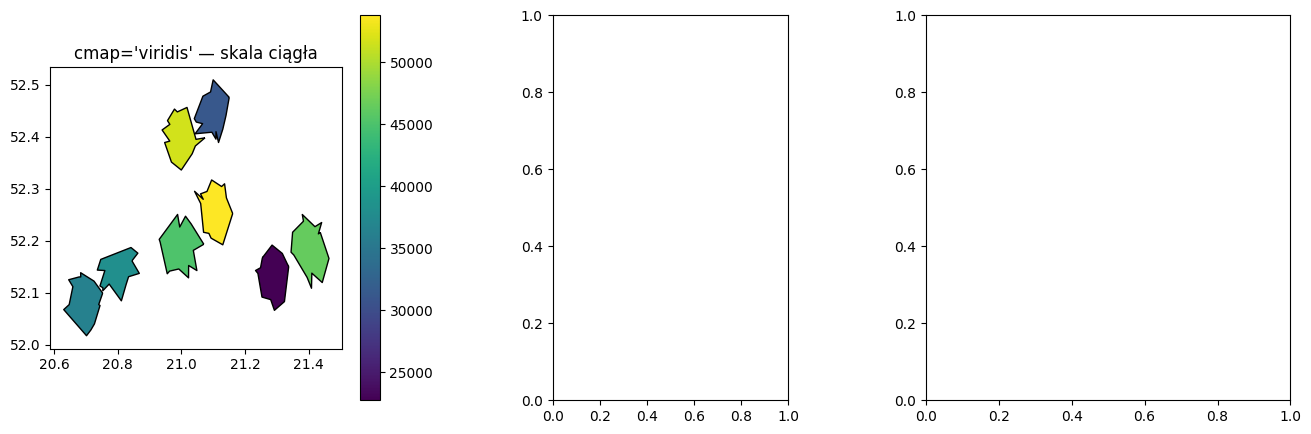

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

gminy.plot(column="ludnosc", cmap="viridis", legend=True, edgecolor="black", ax=axes[0])
axes[0].set_title("cmap='viridis' — skala ciągła")

gminy.plot(column="ludnosc", cmap="OrRd", scheme="quantiles", k=4,
           legend=True, edgecolor="black", ax=axes[1])
axes[1].set_title("scheme='quantiles', k=4")

paleta = sns.color_palette("Set2", n_colors=gminy["powiat"].nunique())
mapa_kolorow = dict(zip(gminy["powiat"].unique(), paleta))
gminy.plot(color=gminy["powiat"].map(mapa_kolorow), edgecolor="black", ax=axes[2])
axes[2].set_title("kategorie — paleta seaborn")

## 21. łączenie z innymi bibliotekami

### scikit-learn — klastrowanie przestrzenne (DBSCAN)

QGIS ma do tego algorytm *DBSCAN Clustering* — w Pythonie to jedna linia
na współrzędnych z warstwy metrycznej (`eps` w metrach ma wtedy
bezpośrednią interpretację). Łączy geoanalizę z ML z Twojej ścieżki
rozwoju jednym wywołaniem.

liczba klastrów (bez szumu -1): 2


<Axes: >

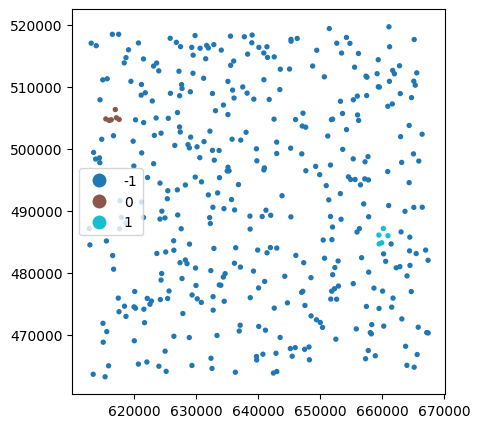

In [ ]:
from sklearn.cluster import DBSCAN

etykiety = DBSCAN(eps=1500, min_samples=5).fit_predict(wspolrzedne)
lokalizacje_2180["klaster"] = etykiety

print("liczba klastrów (bez szumu -1):", len(set(etykiety) - {-1}))
lokalizacje_2180.plot(column="klaster", categorical=True, legend=True, markersize=8, figsize=(5, 5))

### GeoParquet — nowoczesny format wymiany, zamiast SHP/GPKG

Parquet z zachowaną geometrią i CRS w metadanych — czytany bezpośrednio
przez DuckDB (`spatial` extension, patrz osobny notebook o DuckDB) bez
przechodzenia przez GeoPandas.

In [ ]:
gminy.to_parquet(dane_dir / "gminy.parquet")
wczytane = gpd.read_parquet(dane_dir / "gminy.parquet")
print("CRS zachowany w metadanych pliku:", wczytane.crs)

CRS zachowany w metadanych pliku: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit":

### Inne warte odnotowania (kod referencyjny — wymaga sieci, nie wykonywany tutaj)

- **`contextily`** — kafle OSM jako tło pod statyczny `.plot()`.
- **DuckDB `spatial`** — przy bardzo dużych joinach przestrzennych bywa
  szybszy niż `gpd.sjoin`.

In [ ]:
# import contextily as cx
# ax = gminy_2180.to_crs(epsg=3857).plot(alpha=0.5, edgecolor="black", figsize=(6, 5))
# cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

# duckdb.sql("INSTALL spatial; LOAD spatial;")
# duckdb.sql("""
#     SELECT p.*, g.nazwa FROM read_parquet('lokalizacje.parquet') AS p
#     JOIN ST_Read('gminy.gpkg') AS g ON ST_Within(ST_Point(p.lon, p.lat), g.geom)
# """).df()

## 22. Zapisywanie wyników

In [ ]:
siatka.to_file(dane_dir / "warstwy.gpkg", layer="siatka_zliczenia", driver="GPKG")
punkty_z_gmina.drop(columns=["index_right"]).to_file(
    dane_dir / "warstwy.gpkg", layer="punkty_z_agregacja", driver="GPKG"
)
print("warstwy w warstwy.gpkg:", gpd.list_layers(dane_dir / "warstwy.gpkg")["name"].tolist())

warstwy w warstwy.gpkg: ['gminy', 'strefy', 'gminy_centralny', 'gminy_polnocny', 'gminy_wschodni', 'gminy_zachodni', 'siatka_zliczenia', 'punkty_z_agregacja']


## 23. Wizualizacja zbiorcza

Text(0.5, 1.0, 'Gminy (wg ludności) + strefy (kontur) + lokalizacje')

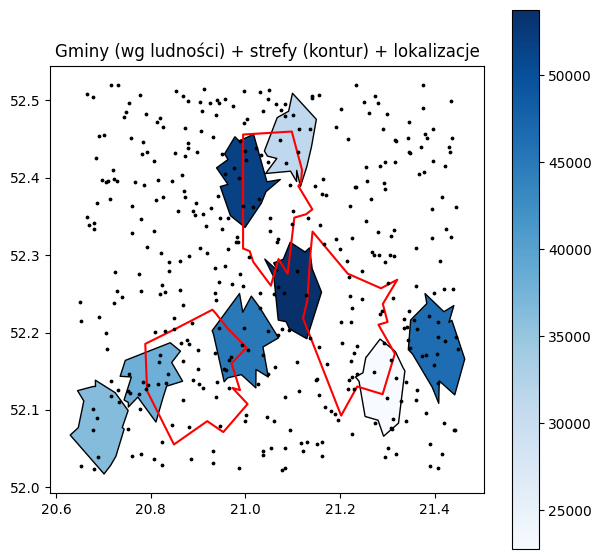

In [ ]:
ax = gminy.plot(column="ludnosc", cmap="Blues", legend=True, edgecolor="black", figsize=(7, 7))
strefy.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=1.5)
lokalizacje.plot(ax=ax, color="black", markersize=3)
ax.set_title("Gminy (wg ludności) + strefy (kontur) + lokalizacje")

In [ ]:
# m = gminy.explore(column="ludnosc", cmap="Blues", tooltip="nazwa")
# lokalizacje.explore(m=m, color="black", marker_kwds={"radius": 3})
print("gpd.explore() — patrz komentarz wyżej")

gpd.explore() — patrz komentarz wyżej
